In [1]:
!uv add "langgraph==1.2.9" "langchain-groq==1.1.3" "python-dotenv>=1.0.1" "ipykernel>=7.0.0"

Resolved 71 packages in 2ms
Prepared 4 packages in 164ms                                                 pyyaml               ------------------------------ 779.00 KiB/788.94 KiB       pyyaml               ------------------------------ 763.00 KiB/788.94 KiB       pyyaml               ------------------------------ 603.00 KiB/788.94 KiB       pyyaml               ------------------------------ 16.00 KiB/788.94 KiB        
░░░░░░░░░░░░░░░░░░░░ [0/36] Installing wheels...                                warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 36 packages in 1.94s                              
 + annotated-types==0.7.0
 + anyio==4.14.2
 + certifi==2026.7.22
 + charset-normalizer==3.4.9
 + distro==1.

In [2]:
from typing import List, Optional, TypedDict

In [3]:
class AgentState(TypedDict, total=False):
    user_input: str
    task_list: List[str]
    final_output: Optional[str]

In [4]:
import os

groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise RuntimeError("GROQ_API_KEY is not available. Rebuild the Codespace after adding the secret.")

In [13]:
from langchain_groq import ChatGroq
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x72aa03f45d90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72aa10030c80>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [15]:
def planner_node(state: dict) -> dict:
    prompt = f"Break this task into 2-3 steps: {state['user_input']}"
    response  = llm.invoke(prompt)  # Assuming you have a function defined to call the LLM
    steps = response.content
    step_lines = [line.strip("- ").strip() for line in steps.split("\n") if line.strip()]
    print("📌 Planner temp Output:", step_lines[0] if step_lines else "No steps generated")
    print("📌 Planner Output:", step_lines)
    return {"task_list": step_lines}

In [16]:
def executor_node(state: dict) -> dict:
    steps = state.get("task_list", [])
    final_output = " -> ".join(steps) + " -> Done!"
    return {"final_output": final_output}

In [ ]:
import langgraph.graph

In [17]:
from langgraph.graph import StateGraph

In [18]:
graph = StateGraph(state_schema=AgentState)

In [19]:
graph.add_node("planner", planner_node)
graph.add_node("executor", executor_node)

graph.set_entry_point("planner")
graph.add_edge("planner", "executor")
graph.set_finish_point("executor")

In [20]:
graph_compiled = graph.compile()

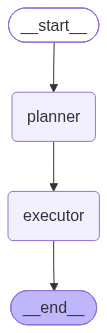

In [21]:
from IPython.display import Image, display
try:
    display(Image(graph_compiled.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [22]:
state = {"user_input": "How do solar panels work?"}
final_state = graph_compiled.invoke(state)

📌 Planner temp Output: To understand how solar panels work, we can break the process down into 3 main steps:
📌 Planner Output: ['To understand how solar panels work, we can break the process down into 3 main steps:', '1. **Conversion of Sunlight to Energy**: Solar panels are made up of photovoltaic (PV) cells, which are designed to convert sunlight into electrical energy. When sunlight hits a PV cell, it excites the electrons in the cell, causing them to flow through the material and create an electrical current.', "2. **Collection and Transfer of Energy**: The electrical current generated by the PV cells is collected by the solar panel's internal wiring and transferred to an inverter. The inverter is a device that converts the direct current (DC) energy produced by the solar panel into alternating current (AC) energy, which is usable in homes and businesses.", "3. **Distribution and Use of Energy**: The AC energy produced by the inverter is then fed into the electrical grid, where it 

In [23]:
print(final_state["final_output"])

To understand how solar panels work, we can break the process down into 3 main steps: -> 1. **Conversion of Sunlight to Energy**: Solar panels are made up of photovoltaic (PV) cells, which are designed to convert sunlight into electrical energy. When sunlight hits a PV cell, it excites the electrons in the cell, causing them to flow through the material and create an electrical current. -> 2. **Collection and Transfer of Energy**: The electrical current generated by the PV cells is collected by the solar panel's internal wiring and transferred to an inverter. The inverter is a device that converts the direct current (DC) energy produced by the solar panel into alternating current (AC) energy, which is usable in homes and businesses. -> 3. **Distribution and Use of Energy**: The AC energy produced by the inverter is then fed into the electrical grid, where it can be used to power electrical devices, or stored in a battery for later use. The energy can also be sold back to the grid if it